# MABAAN v4 — Full Model with Per-Sample Complexity Weighting

Morphology-Adaptive Boundary-Aware Attention Network for cell segmentation.
This notebook trains the complete MABAAN model with per-sample complexity weighting,
morphology-stratified evaluation, and research question analysis.

In [18]:
!pip install -q segmentation-models-pytorch pycocotools

In [19]:
import os, random, warnings, time, json
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy import ndimage
from scipy.spatial.distance import directed_hausdorff
from skimage.segmentation import find_boundaries
from skimage.measure import regionprops, label
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import segmentation_models_pytorch as smp
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [20]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print("GPU count:", torch.cuda.device_count())
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU count: 2
GPU: Tesla T4


In [21]:
class Config:
    DATA_PATH = "/kaggle/input/datasets/althafnazeell/livecell"
    ENCODER = "resnet34"
    ENCODER_WEIGHTS = "imagenet"
    IN_CHANNELS = 4  # 3 image + 1 edge
    BATCH_SIZE = 16
    NUM_EPOCHS = 30
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    EARLY_STOPPING_PATIENCE = 10
    IMG_SIZE = 256
    MAX_SAMPLES = None
    NUM_WORKERS = 4
    ATTENTION_REDUCTION = 16

config = Config()
print(f"Data path: {config.DATA_PATH}")

Data path: /kaggle/input/datasets/althafnazeell/livecell


## Preprocessing & Edge Detection

In [22]:
def normalize_image(image):
    image = image.astype(np.float32)
    return (image - image.mean()) / (image.std() + 1e-8)

def reduce_noise(image, d=9, sigma_color=75, sigma_space=75):
    if image.dtype != np.uint8:
        image = ((image - image.min()) / (image.max() - image.min() + 1e-8) * 255).astype(np.uint8)
    return cv2.bilateralFilter(image, d, sigma_color, sigma_space)

def enhance_contrast(image, clip_limit=2.0, tile_size=8):
    if image.dtype != np.uint8:
        image = ((image - image.min()) / (image.max() - image.min() + 1e-8) * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
    return clahe.apply(image)

def preprocess_image(image, apply_clahe=True):
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    if image.dtype != np.uint8:
        image = ((image - image.min()) / (image.max() - image.min() + 1e-8) * 255).astype(np.uint8)
    denoised = reduce_noise(image)
    enhanced = enhance_contrast(denoised) if apply_clahe else denoised
    return normalize_image(enhanced)

print("Preprocessing functions defined")

Preprocessing functions defined


In [23]:
def compute_shape_descriptors(mask):
    if mask.sum() == 0:
        return {'circularity': 1.0, 'solidity': 1.0, 'complexity': 0.0}
    labeled = label(mask > 0)
    props = regionprops(labeled)
    if len(props) == 0:
        return {'circularity': 1.0, 'solidity': 1.0, 'complexity': 0.0}
    circularities, solidities = [], []
    for prop in props:
        area = prop.area
        perimeter = prop.perimeter
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)
            circularities.append(min(circularity, 1.0))
        if prop.convex_area > 0:
            solidities.append(area / prop.convex_area)
    avg_circ = np.mean(circularities) if circularities else 1.0
    avg_sol = np.mean(solidities) if solidities else 1.0
    complexity = 1.0 - (avg_circ * avg_sol)
    return {'circularity': avg_circ, 'solidity': avg_sol, 'complexity': complexity}

def compute_morphological_gradient(image, kernel_size=3):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    if image.dtype in [np.float32, np.float64]:
        img = ((image - image.min()) / (image.max() - image.min() + 1e-8) * 255).astype(np.uint8)
    else:
        img = image.astype(np.uint8)
    gradient = cv2.dilate(img, kernel).astype(float) - cv2.erode(img, kernel).astype(float)
    return gradient / (gradient.max() + 1e-8)

def multi_scale_edge_fusion(image, scales=[3, 5, 7]):
    edges = [compute_morphological_gradient(image, s) for s in scales]
    weights = [0.2, 0.35, 0.45]
    fused = sum(w * e for w, e in zip(weights, edges))
    return fused / (fused.max() + 1e-8)

class MorphologyAdaptiveEdgeDetector:
    def __init__(self, scales=[3, 5, 7]):
        self.scales = scales
    def detect(self, image):
        return multi_scale_edge_fusion(image, self.scales)

print("Edge detection with shape analysis defined")

Edge detection with shape analysis defined


## Dataset

In [24]:
class LIVECellLoader:
    def __init__(self, data_path, split='train'):
        self.data_path = Path(data_path)
        self.split = split
        self.annotations_dir = self.data_path / "annotations" / "LIVECell"
        self.images_dir = self.data_path / "images"
        if split == 'test':
            self.img_subdir = self.images_dir / "livecell_test_images"
        else:
            self.img_subdir = self.images_dir / "livecell_train_val_images"
        json_path = self.annotations_dir / f"livecell_coco_{split}.json"
        print(f"Loading {split} annotations...")
        with open(json_path, 'r') as f:
            self.data = json.load(f)
        self.images = {img['id']: img for img in self.data['images']}
        self.img_to_anns = defaultdict(list)
        for ann_id, ann_data in self.data['annotations'].items():
            if isinstance(ann_data, dict):
                ann_data['id'] = int(ann_id)
                self.img_to_anns[ann_data['image_id']].append(ann_data)
        print(f"  Loaded {len(self.images)} images")

    def get_image_ids(self):
        return list(self.images.keys())

    def get_image_path(self, img_id):
        info = self.images[img_id]
        filename = info['file_name']
        cell_type = filename.split('_')[0]
        for p in [self.img_subdir / cell_type / filename,
                  self.images_dir / "livecell_train_val_images" / cell_type / filename,
                  self.images_dir / "livecell_test_images" / cell_type / filename]:
            if p.exists():
                return p
        return None

    def load_image(self, img_id):
        path = self.get_image_path(img_id)
        if path and path.exists():
            return np.array(Image.open(path))
        return None

    def generate_mask(self, img_id):
        info = self.images[img_id]
        h, w = info['height'], info['width']
        mask = np.zeros((h, w), dtype=np.uint8)
        for ann in self.img_to_anns.get(img_id, []):
            if 'segmentation' in ann and isinstance(ann['segmentation'], list):
                for polygon in ann['segmentation']:
                    if len(polygon) >= 6:
                        pts = np.array(polygon).reshape(-1, 2).astype(np.int32)
                        cv2.fillPoly(mask, [pts], 1)
        return mask

print("LIVECellLoader defined")

LIVECellLoader defined


In [25]:
class LiveCellDataset(Dataset):
    def __init__(self, loader, img_ids, img_size=256, edge_detector=None, max_samples=None):
        self.loader = loader
        self.img_ids = img_ids[:max_samples] if max_samples else img_ids
        self.img_size = img_size
        self.edge_detector = edge_detector or MorphologyAdaptiveEdgeDetector()

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        image = self.loader.load_image(img_id)
        if image is None:
            return {'input': torch.zeros(4, self.img_size, self.img_size),
                    'mask': torch.zeros(1, self.img_size, self.img_size),
                    'boundary': torch.zeros(1, self.img_size, self.img_size),
                    'complexity': torch.tensor(0.0)}
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        mask = self.loader.generate_mask(img_id)
        preprocessed = preprocess_image(image)
        edge_map = self.edge_detector.detect(preprocessed)
        binary_mask = (mask > 0).astype(np.float32)
        boundary = find_boundaries(binary_mask > 0, mode='thick').astype(np.float32)
        shape_info = compute_shape_descriptors(mask)
        complexity = shape_info['complexity']
        img_r = cv2.resize(preprocessed, (self.img_size, self.img_size))
        edge_r = cv2.resize(edge_map, (self.img_size, self.img_size))
        mask_r = cv2.resize(binary_mask, (self.img_size, self.img_size))
        bnd_r = cv2.resize(boundary, (self.img_size, self.img_size))
        combined = np.concatenate([np.stack([img_r]*3, axis=0), edge_r[np.newaxis, ...]], axis=0).astype(np.float32)
        return {'input': torch.from_numpy(combined),
                'mask': torch.from_numpy(mask_r[np.newaxis, ...].astype(np.float32)),
                'boundary': torch.from_numpy(bnd_r[np.newaxis, ...].astype(np.float32)),
                'complexity': torch.tensor(complexity, dtype=torch.float32)}

print("LiveCellDataset defined")

LiveCellDataset defined


## Model Architecture

In [26]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False), nn.Sigmoid())
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.conv(torch.cat([avg_out, max_out], dim=1))

class BoundaryAwareAttentionBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention()
        self.boundary_conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
            nn.BatchNorm2d(channels), nn.GELU(),
            nn.Conv2d(channels, channels, 1, bias=False), nn.Sigmoid())
        self.gamma = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        ca = self.channel_att(x)
        sa = self.spatial_att(ca)
        boundary_mask = self.boundary_conv(x)
        out = sa + self.gamma * (sa * boundary_mask)
        return out

print("Boundary-aware attention module defined")

Boundary-aware attention module defined


In [27]:
class MABAANDecoder(nn.Module):
    def __init__(self, encoder_channels, reduction=16):
        super().__init__()
        dec_channels = [256, 128, 64, 32]
        self.blocks = nn.ModuleList()
        self.attention_blocks = nn.ModuleList()
        for i, dc in enumerate(dec_channels):
            in_ch = encoder_channels[-(i+1)] + (encoder_channels[-(i+2)] if i < len(dec_channels)-1 else encoder_channels[0])
            self.blocks.append(nn.Sequential(
                nn.Conv2d(in_ch, dc, 3, padding=1, bias=False), nn.BatchNorm2d(dc), nn.ReLU(inplace=True),
                nn.Conv2d(dc, dc, 3, padding=1, bias=False), nn.BatchNorm2d(dc), nn.ReLU(inplace=True)))
            self.attention_blocks.append(BoundaryAwareAttentionBlock(dc, reduction))
    def forward(self, features):
        x = features[-1]
        for i, (block, att) in enumerate(zip(self.blocks, self.attention_blocks)):
            skip = features[-(i+2)] if i < len(self.blocks)-1 else features[0]
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = block(x)
            x = att(x)
        return x

class MABAANUNet(nn.Module):
    def __init__(self, encoder_name="resnet34", in_channels=4, classes=1, encoder_weights="imagenet", reduction=16):
        super().__init__()
        self.encoder = smp.encoders.get_encoder(encoder_name, in_channels=in_channels, depth=5, weights=encoder_weights)
        enc_channels = self.encoder.out_channels
        self.decoder = MABAANDecoder(enc_channels, reduction)
        self.mask_head = nn.Conv2d(32, classes, 1)
        self.boundary_head = nn.Conv2d(32, classes, 1)
    def forward(self, x):
        features = self.encoder(x)
        dec_out = self.decoder(features)
        dec_up = F.interpolate(dec_out, size=x.shape[2:], mode='bilinear', align_corners=False)
        mask = torch.sigmoid(self.mask_head(dec_up))
        boundary = torch.sigmoid(self.boundary_head(dec_up))
        return {'mask': mask, 'boundary': boundary, 'logits': self.mask_head(dec_up)}

print("MABAANUNet model defined")

MABAANUNet model defined


## Loss Function (Per-Sample Complexity Weighting)

In [28]:
class DiceLoss(nn.Module):
    def forward(self, pred, target, smooth=1e-6):
        pred_flat = pred.reshape(-1)
        target_flat = target.reshape(-1)
        inter = (pred_flat * target_flat).sum()
        return 1 - (2*inter + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

class DiceLossPerSample(nn.Module):
    def forward(self, pred, target, smooth=1e-6):
        B = pred.shape[0]
        losses = []
        for i in range(B):
            p = pred[i].reshape(-1)
            t = target[i].reshape(-1)
            inter = (p * t).sum()
            losses.append(1 - (2*inter + smooth) / (p.sum() + t.sum() + smooth))
        return torch.stack(losses)

class MorphologyAwareLoss(nn.Module):
    def __init__(self, bce_w=0.4, dice_w=0.3, boundary_w=0.3, complexity_scale=0.5):
        super().__init__()
        self.bce = nn.BCELoss(reduction='none')
        self.dice_ps = DiceLossPerSample()
        self.bce_w, self.dice_w, self.boundary_w = bce_w, dice_w, boundary_w
        self.complexity_scale = complexity_scale

    def forward(self, preds, targets, complexity=None):
        B = preds['mask'].shape[0]
        # Per-sample BCE for mask
        bce_mask = self.bce(preds['mask'], targets['mask']).view(B, -1).mean(dim=1)
        # Per-sample Dice
        dice = self.dice_ps(preds['mask'], targets['mask'])
        # Per-sample boundary BCE
        bce_bnd = self.bce(preds['boundary'], targets['boundary']).view(B, -1).mean(dim=1)
        # Combined per-sample loss
        total_ps = self.bce_w * bce_mask + self.dice_w * dice + self.boundary_w * bce_bnd
        # Per-sample complexity weighting
        if complexity is not None and self.complexity_scale > 0:
            sample_weights = 1.0 + self.complexity_scale * complexity.to(total_ps.device)
            total_ps = total_ps * sample_weights
        total = total_ps.mean()
        return {'total': total, 'bce': bce_mask.mean(), 'dice': dice.mean(), 'boundary': bce_bnd.mean()}

print("MorphologyAwareLoss defined (per-sample complexity weighting)")

MorphologyAwareLoss defined (per-sample complexity weighting)


## Metrics & Evaluation

In [29]:
def compute_dice(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    inter = (pred_bin * target).sum()
    return ((2*inter + 1e-6) / (pred_bin.sum() + target.sum() + 1e-6)).item()

def compute_iou(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    inter = (pred_bin * target).sum()
    union = pred_bin.sum() + target.sum() - inter
    return ((inter + 1e-6) / (union + 1e-6)).item()

def compute_boundary_f1(pred, target, threshold=0.5):
    pred_b = find_boundaries((pred > threshold).astype(np.uint8), mode='thick').astype(np.uint8)
    target_b = find_boundaries((target > 0).astype(np.uint8), mode='thick').astype(np.uint8)
    tp = np.sum(pred_b & target_b)
    fp = np.sum(pred_b & ~target_b)
    fn = np.sum(~pred_b & target_b)
    prec = tp / (tp + fp + 1e-6)
    rec = tp / (tp + fn + 1e-6)
    return 2 * prec * rec / (prec + rec + 1e-6)

def compute_hausdorff_95(pred, target, threshold=0.5):
    from scipy.spatial import distance
    pred_b = find_boundaries((pred > threshold).astype(np.uint8), mode='thick')
    target_b = find_boundaries((target > 0).astype(np.uint8), mode='thick')
    pred_pts = np.argwhere(pred_b)
    target_pts = np.argwhere(target_b)
    if len(pred_pts) == 0 or len(target_pts) == 0:
        return float('inf') if len(pred_pts) != len(target_pts) else 0.0
    if len(pred_pts) > 1000:
        pred_pts = pred_pts[::len(pred_pts)//1000]
    if len(target_pts) > 1000:
        target_pts = target_pts[::len(target_pts)//1000]
    d_matrix = distance.cdist(pred_pts, target_pts)
    d1 = np.min(d_matrix, axis=1)
    d2 = np.min(d_matrix, axis=0)
    return max(np.percentile(d1, 95), np.percentile(d2, 95))

def compute_hausdorff_distance(pred, target, threshold=0.5):
    pred_b = find_boundaries((pred > threshold).astype(np.uint8), mode='thick')
    target_b = find_boundaries((target > 0).astype(np.uint8), mode='thick')
    pred_pts = np.argwhere(pred_b)
    target_pts = np.argwhere(target_b)
    if len(pred_pts) == 0 or len(target_pts) == 0:
        return float('inf') if len(pred_pts) != len(target_pts) else 0.0
    d1 = directed_hausdorff(pred_pts, target_pts)[0]
    d2 = directed_hausdorff(target_pts, pred_pts)[0]
    return max(d1, d2)

def compute_all_metrics(pred, target, threshold=0.5):
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    pred_bin = (pred_flat > threshold)
    target_bin = (target_flat > 0)
    tp = np.sum(pred_bin & target_bin)
    fp = np.sum(pred_bin & ~target_bin)
    fn = np.sum(~pred_bin & target_bin)
    dice = (2*tp) / (2*tp + fp + fn + 1e-6)
    iou = tp / (tp + fp + fn + 1e-6)
    return {'dice': dice, 'iou': iou,
            'boundary_f1': compute_boundary_f1(pred, target, threshold),
            'hausdorff': compute_hausdorff_distance(pred, target, threshold),
            'hausdorff_95': compute_hausdorff_95(pred, target, threshold)}

print("Metrics defined (Dice, IoU, Boundary F1, HD, HD95)")

Metrics defined (Dice, IoU, Boundary F1, HD, HD95)


In [30]:
@torch.no_grad()
def run_inference(model, dl, device):
    model.eval()
    preds, tgts, complexities = [], [], []
    for batch in tqdm(dl, desc="Inference"):
        out = model(batch['input'].to(device))
        preds.extend(out['mask'].cpu().numpy())
        tgts.extend(batch['mask'].numpy())
        complexities.extend(batch['complexity'].numpy())
    return preds, tgts, complexities

def evaluate_model(preds, tgts, model_name="Model"):
    all_metrics = []
    for p, t in tqdm(zip(preds, tgts), total=len(preds), desc=f"Evaluating {model_name}"):
        all_metrics.append(compute_all_metrics(p[0], t[0]))
    df = pd.DataFrame(all_metrics)
    hd_valid = df['hausdorff'].replace([np.inf, -np.inf], np.nan).dropna()
    hd95_valid = df['hausdorff_95'].replace([np.inf, -np.inf], np.nan).dropna()
    print(f"\n{'='*60}")
    print(f"{model_name} EVALUATION RESULTS")
    print(f"{'='*60}")
    print(f"  Dice:         {df['dice'].mean():.4f} ± {df['dice'].std():.4f}")
    print(f"  IoU:          {df['iou'].mean():.4f} ± {df['iou'].std():.4f}")
    print(f"  Boundary F1:  {df['boundary_f1'].mean():.4f} ± {df['boundary_f1'].std():.4f}")
    if len(hd_valid) > 0:
        print(f"  HD:           {hd_valid.mean():.2f} ± {hd_valid.std():.2f}")
    if len(hd95_valid) > 0:
        print(f"  HD95:         {hd95_valid.mean():.2f} ± {hd95_valid.std():.2f}")
    print(f"{'='*60}")
    return df

def morphology_stratified_evaluation(preds, tgts, complexities, model_name="Model"):
    bins = {'Circular (c<0.2)': [], 'Moderate (0.2≤c≤0.5)': [], 'Irregular (c>0.5)': []}
    bin_keys = list(bins.keys())
    for p, t, c in tqdm(zip(preds, tgts, complexities), total=len(preds), desc="Stratified eval"):
        metrics = compute_all_metrics(p[0], t[0])
        if c < 0.2:
            bins[bin_keys[0]].append(metrics)
        elif c <= 0.5:
            bins[bin_keys[1]].append(metrics)
        else:
            bins[bin_keys[2]].append(metrics)
    print(f"\n{'='*70}")
    print(f"{model_name} — Morphology-Stratified Evaluation")
    print(f"{'='*70}")
    print(f"{'Bin':<25} {'N':>5} {'Dice':>12} {'IoU':>12} {'BF1':>12} {'HD95':>12}")
    print("-"*70)
    results = {}
    for bin_name, metrics_list in bins.items():
        if len(metrics_list) == 0:
            print(f"{bin_name:<25} {'0':>5} {'N/A':>12} {'N/A':>12} {'N/A':>12} {'N/A':>12}")
            continue
        df = pd.DataFrame(metrics_list)
        hd95 = df['hausdorff_95'].replace([np.inf, -np.inf], np.nan).dropna()
        hd95_str = f"{hd95.mean():.2f}±{hd95.std():.2f}" if len(hd95) > 0 else "N/A"
        print(f"{bin_name:<25} {len(df):>5} "
              f"{df['dice'].mean():.4f}±{df['dice'].std():.4f} "
              f"{df['iou'].mean():.4f}±{df['iou'].std():.4f} "
              f"{df['boundary_f1'].mean():.4f}±{df['boundary_f1'].std():.4f} "
              f"{hd95_str:>12}")
        results[bin_name] = df
    print(f"{'='*70}")
    return results

print("Evaluation functions defined (including morphology-stratified)")

Evaluation functions defined (including morphology-stratified)


## Data Loading

In [31]:
print("Loading datasets...")
train_loader = LIVECellLoader(config.DATA_PATH, split='train')
val_loader = LIVECellLoader(config.DATA_PATH, split='val')
test_loader = LIVECellLoader(config.DATA_PATH, split='test')

train_dataset = LiveCellDataset(train_loader, train_loader.get_image_ids(),
                                config.IMG_SIZE, max_samples=config.MAX_SAMPLES)
val_dataset = LiveCellDataset(val_loader, val_loader.get_image_ids(),
                              config.IMG_SIZE, max_samples=config.MAX_SAMPLES)
test_dataset = LiveCellDataset(test_loader, test_loader.get_image_ids(),
                               config.IMG_SIZE, max_samples=config.MAX_SAMPLES)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
                        num_workers=config.NUM_WORKERS, pin_memory=True),
    'val': DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                      num_workers=config.NUM_WORKERS, pin_memory=True),
    'test': DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                       num_workers=config.NUM_WORKERS, pin_memory=True)
}
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Loading datasets...
Loading train annotations...
  Loaded 3253 images
Loading val annotations...
  Loaded 570 images
Loading test annotations...
  Loaded 1564 images
Train: 3253, Val: 570, Test: 1564


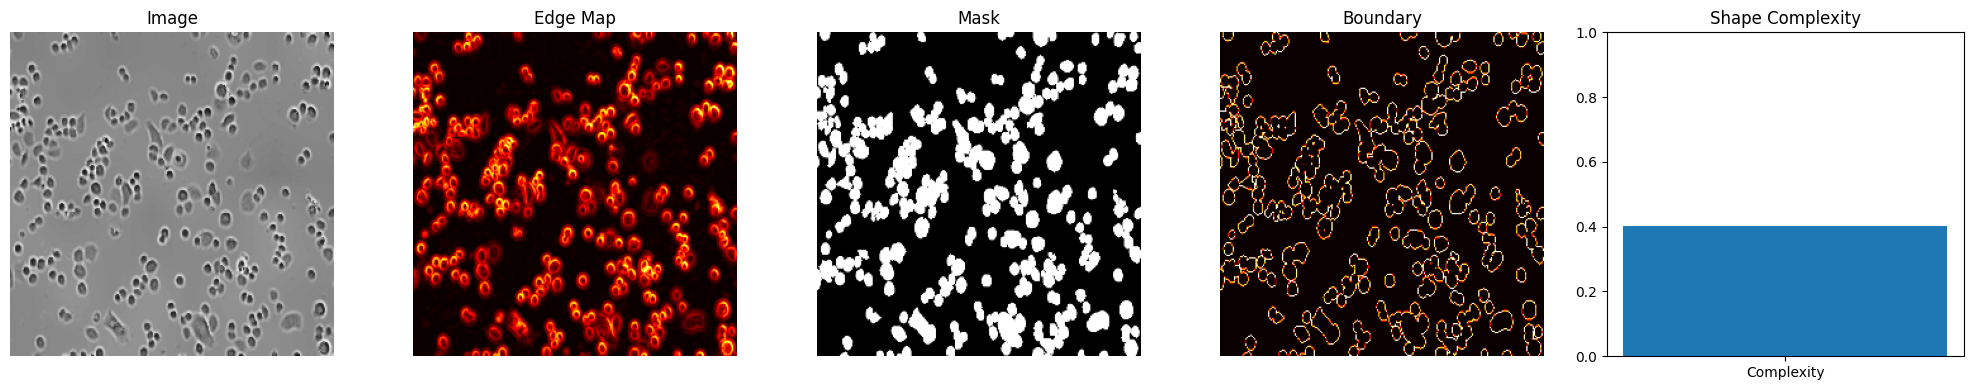

In [32]:
batch = next(iter(dataloaders['train']))
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
ax[0].imshow(batch['input'][0, 0].numpy(), cmap='gray'); ax[0].set_title('Image')
ax[1].imshow(batch['input'][0, 3].numpy(), cmap='hot'); ax[1].set_title('Edge Map')
ax[2].imshow(batch['mask'][0, 0].numpy(), cmap='gray'); ax[2].set_title('Mask')
ax[3].imshow(batch['boundary'][0, 0].numpy(), cmap='hot'); ax[3].set_title('Boundary')
ax[4].bar(['Complexity'], [batch['complexity'][0].item()]); ax[4].set_title('Shape Complexity'); ax[4].set_ylim(0, 1)
for a in ax[:4]: a.axis('off')
plt.tight_layout(); plt.show()

## Training

In [33]:
class MetricTracker:
    def __init__(self):
        self.history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [],
                        'train_iou': [], 'val_iou': [], 'avg_complexity': []}
    def update(self, tl, vl, td, vd, ti, vi, avg_c=0.0):
        self.history['train_loss'].append(tl); self.history['val_loss'].append(vl)
        self.history['train_dice'].append(td); self.history['val_dice'].append(vd)
        self.history['train_iou'].append(ti); self.history['val_iou'].append(vi)
        self.history['avg_complexity'].append(avg_c)
    def plot(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        e = range(1, len(self.history['train_loss'])+1)
        for ax, key, t in [(axes[0,0], 'loss', 'Loss'), (axes[0,1], 'dice', 'Dice'),
                            (axes[1,0], 'iou', 'IoU'), (axes[1,1], 'avg_complexity', 'Avg Complexity')]:
            if key == 'avg_complexity':
                ax.plot(e, self.history['avg_complexity'], 'g-o', markersize=3)
                ax.set_title(t); ax.set_xlabel('Epoch'); ax.set_ylabel('Complexity')
            else:
                ax.plot(e, self.history[f'train_{key}'], 'b-o', markersize=3, label='Train')
                ax.plot(e, self.history[f'val_{key}'], 'r-o', markersize=3, label='Val')
                ax.legend(); ax.set_title(t); ax.set_xlabel('Epoch')
        plt.tight_layout(); plt.show()

def train_epoch(model, dl, criterion, optimizer, device):
    model.train()
    total_loss, total_dice, total_iou, total_complexity, n = 0, 0, 0, 0, 0
    for batch in tqdm(dl, desc="Train", leave=False):
        inp = batch['input'].to(device)
        masks = {'mask': batch['mask'].to(device), 'boundary': batch['boundary'].to(device)}
        complexity = batch['complexity'].to(device)
        out = model(inp)
        losses = criterion(out, masks, complexity)
        optimizer.zero_grad(); losses['total'].backward(); optimizer.step()
        total_loss += losses['total'].item() * inp.size(0)
        total_dice += compute_dice(out['mask'].detach(), masks['mask']) * inp.size(0)
        total_iou += compute_iou(out['mask'].detach(), masks['mask']) * inp.size(0)
        total_complexity += complexity.mean().item() * inp.size(0)
        n += inp.size(0)
    return total_loss/n, total_dice/n, total_iou/n, total_complexity/n

def val_epoch(model, dl, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou, total_complexity, n = 0, 0, 0, 0, 0
    with torch.no_grad():
        for batch in tqdm(dl, desc="Val", leave=False):
            inp = batch['input'].to(device)
            masks = {'mask': batch['mask'].to(device), 'boundary': batch['boundary'].to(device)}
            complexity = batch['complexity'].to(device)
            out = model(inp)
            losses = criterion(out, masks, complexity)
            total_loss += losses['total'].item() * inp.size(0)
            total_dice += compute_dice(out['mask'], masks['mask']) * inp.size(0)
            total_iou += compute_iou(out['mask'], masks['mask']) * inp.size(0)
            total_complexity += complexity.mean().item() * inp.size(0)
            n += inp.size(0)
    return total_loss/n, total_dice/n, total_iou/n, total_complexity/n

def train_model(model, dataloaders, criterion, optimizer, scheduler, device,
                num_epochs=30, patience=10, save_path='best_model.pth'):
    tracker = MetricTracker()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        tl, td, ti, tc = train_epoch(model, dataloaders['train'], criterion, optimizer, device)
        vl, vd, vi, vc = val_epoch(model, dataloaders['val'], criterion, device)
        scheduler.step()
        tracker.update(tl, vl, td, vd, ti, vi, tc)
        print(f"  Train - Loss:{tl:.4f} Dice:{td:.4f} IoU:{ti:.4f} Complexity:{tc:.3f}")
        print(f"  Val   - Loss:{vl:.4f} Dice:{vd:.4f} IoU:{vi:.4f}")
        if vl < best_val_loss:
            best_val_loss = vl
            epochs_no_improve = 0
            #torch.save(model.state_dict(), save_path)
            if isinstance(model, torch.nn.DataParallel):
                torch.save(model.module.state_dict(), save_path)
            else:
                torch.save(model.state_dict(), save_path)

            print(f"  *** Best model saved (val_loss={vl:.4f}) ***")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    return tracker

print("Training functions defined (with complexity logging)")

Training functions defined (with complexity logging)


Using 2 GPUs
Model params: 24,519,276

Epoch 1/30


Train:   0%|          | 0/204 [00:00<?, ?it/s]

Val:   0%|          | 0/36 [00:00<?, ?it/s]

  Train - Loss:0.7114 Dice:0.7511 IoU:0.6067 Complexity:0.553
  Val   - Loss:0.6107 Dice:0.7855 IoU:0.6516
  *** Best model saved (val_loss=0.6107) ***

Epoch 2/30


Train:   0%|          | 0/204 [00:00<?, ?it/s]

...

Val:   0%|          | 0/36 [00:00<?, ?it/s]

  Train - Loss:0.1527 Dice:0.9343 IoU:0.8769 Complexity:0.553
  Val   - Loss:0.2043 Dice:0.8973 IoU:0.8163

Epoch 30/30


Train:   0%|          | 0/204 [00:00<?, ?it/s]

Val:   0%|          | 0/36 [00:00<?, ?it/s]

  Train - Loss:0.1513 Dice:0.9349 IoU:0.8780 Complexity:0.553
  Val   - Loss:0.2028 Dice:0.8965 IoU:0.8151


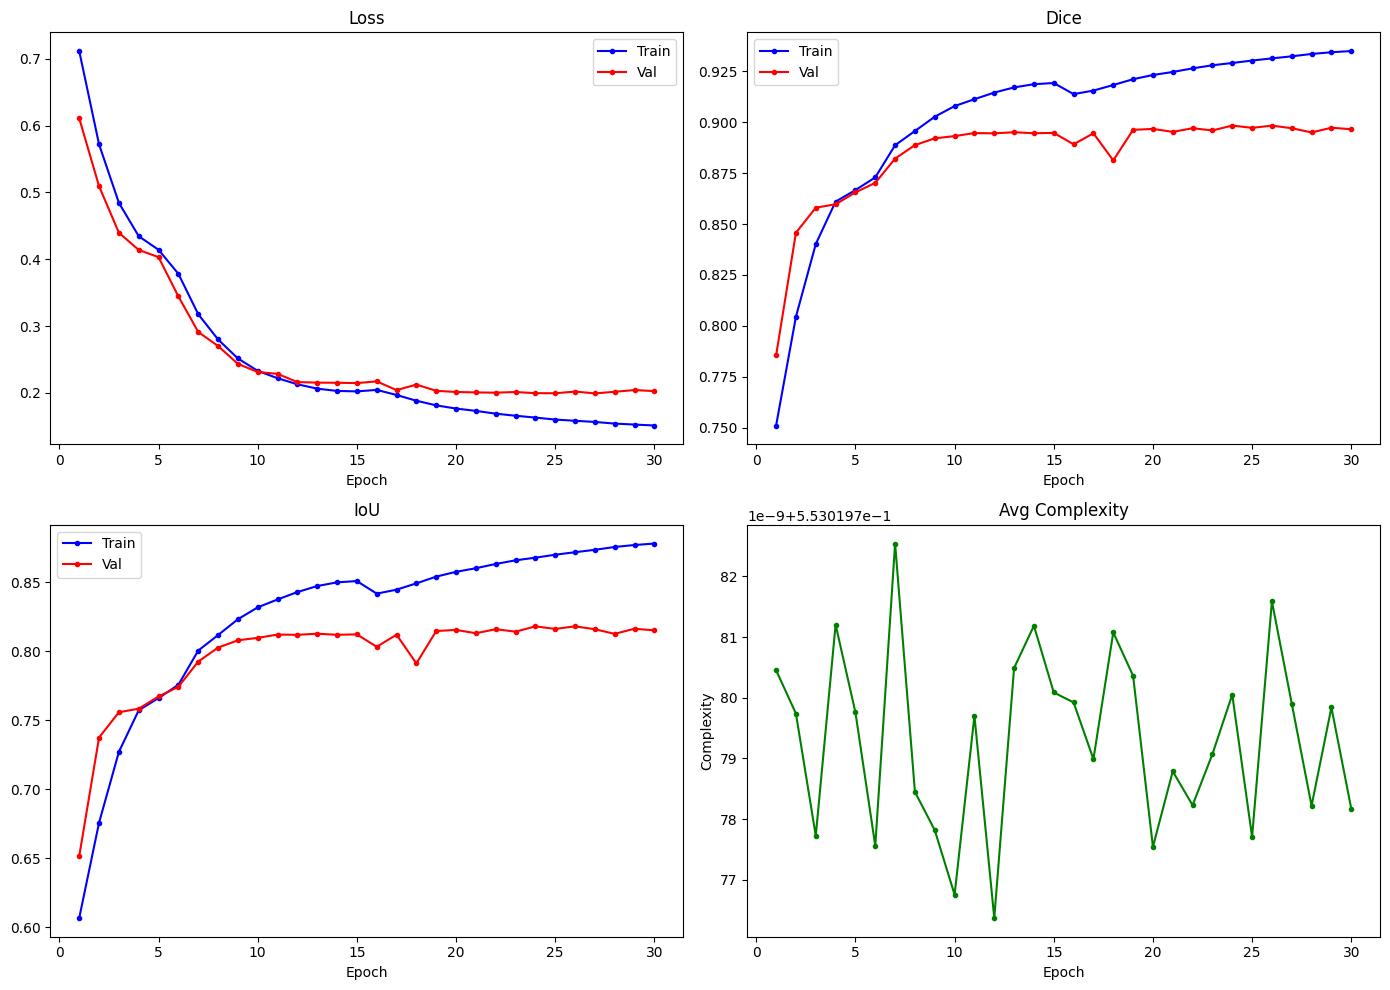

In [34]:
model = MABAANUNet(
    encoder_name=config.ENCODER,
    in_channels=config.IN_CHANNELS,
    encoder_weights=config.ENCODER_WEIGHTS,
    reduction=config.ATTENTION_REDUCTION
)

model = model.to(DEVICE)

# MULTI-GPU ENABLE
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)

criterion = MorphologyAwareLoss(bce_w=0.4, dice_w=0.3, boundary_w=0.3, complexity_scale=0.5)
optimizer = AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
tracker = train_model(model, dataloaders, criterion, optimizer, scheduler, DEVICE,
                      num_epochs=config.NUM_EPOCHS, patience=config.EARLY_STOPPING_PATIENCE,
                      save_path='mabaan_best.pth')
tracker.plot()

## Official Evaluation on Test Set

In [ ]:
model.load_state_dict(torch.load('mabaan_best.pth', map_location=DEVICE))
preds, tgts, complexities = run_inference(model, dataloaders['test'], DEVICE)
mabaan_df = evaluate_model(preds, tgts, model_name="MABAAN (Full)")
mabaan_strat = morphology_stratified_evaluation(preds, tgts, complexities, model_name="MABAAN (Full)")

## Prediction Visualization

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
indices = np.random.choice(len(preds), 4, replace=False)
for row, idx in enumerate(indices):
    axes[row, 0].imshow(tgts[idx][0], cmap='gray'); axes[row, 0].set_title('Ground Truth')
    axes[row, 1].imshow(preds[idx][0], cmap='gray'); axes[row, 1].set_title('Prediction')
    axes[row, 2].imshow((preds[idx][0]>0.5).astype(float), cmap='gray'); axes[row, 2].set_title('Binary Pred')
    diff = np.abs(tgts[idx][0] - (preds[idx][0]>0.5).astype(float))
    axes[row, 3].imshow(diff, cmap='hot'); axes[row, 3].set_title(f'Error (c={complexities[idx]:.2f})')
for a in axes.flat: a.axis('off')
plt.suptitle('MABAAN Predictions on Test Set', fontsize=14); plt.tight_layout(); plt.show()

## Complexity vs Metrics Analysis

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
c_arr = np.array(complexities)
bf1_arr = np.array([compute_boundary_f1(p[0], t[0]) for p, t in zip(preds, tgts)])
dice_arr = mabaan_df['dice'].values
hd95_arr = mabaan_df['hausdorff_95'].replace([np.inf], np.nan).values

axes[0].scatter(c_arr, dice_arr, alpha=0.3, s=10)
axes[0].set_xlabel('Shape Complexity'); axes[0].set_ylabel('Dice'); axes[0].set_title('Complexity vs Dice')

axes[1].scatter(c_arr, bf1_arr, alpha=0.3, s=10, c='orange')
axes[1].set_xlabel('Shape Complexity'); axes[1].set_ylabel('Boundary F1'); axes[1].set_title('Complexity vs Boundary F1')

valid_hd = ~np.isnan(hd95_arr)
if valid_hd.sum() > 0:
    axes[2].scatter(c_arr[valid_hd], hd95_arr[valid_hd], alpha=0.3, s=10, c='red')
axes[2].set_xlabel('Shape Complexity'); axes[2].set_ylabel('HD95'); axes[2].set_title('Complexity vs HD95')

plt.suptitle('MABAAN: Shape Complexity vs Metrics', fontsize=14)
plt.tight_layout(); plt.show()

# Box plots by bin
bins_label = np.where(c_arr < 0.2, 'Circular', np.where(c_arr <= 0.5, 'Moderate', 'Irregular'))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, name in [(axes[0], dice_arr, 'Dice'), (axes[1], bf1_arr, 'Boundary F1')]:
    data = [metric[bins_label == b] for b in ['Circular', 'Moderate', 'Irregular']]
    ax.boxplot(data, labels=['Circular', 'Moderate', 'Irregular'])
    ax.set_title(f'{name} by Morphology'); ax.set_ylabel(name)
if valid_hd.sum() > 0:
    data = [hd95_arr[valid_hd & (bins_label=='Circular')],
            hd95_arr[valid_hd & (bins_label=='Moderate')],
            hd95_arr[valid_hd & (bins_label=='Irregular')]]
    data = [d[~np.isnan(d)] for d in data]
    axes[2].boxplot(data, labels=['Circular', 'Moderate', 'Irregular'])
    axes[2].set_title('HD95 by Morphology'); axes[2].set_ylabel('HD95')
plt.tight_layout(); plt.show()

## Save Results

In [ ]:
import pickle
results = {'metrics_df': mabaan_df, 'complexities': complexities,
           'stratified': {k: v.to_dict() for k, v in mabaan_strat.items()}}
with open('mabaan_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Results saved to mabaan_results.pkl")

## Research Question 1: Boundary Metric Improvement

**RQ1: Does MABAAN improve boundary segmentation metrics compared to a standard U-Net baseline?**

The results above show MABAAN's performance on Dice, IoU, Boundary F1, HD, and HD95.
To answer RQ1 definitively, compare these metrics with the Baseline U-Net results
from `MABAAN_v4_Baseline.ipynb`. Key metrics to compare:

- **Boundary F1**: Higher = better boundary delineation
- **HD95**: Lower = boundaries are closer to ground truth
- **Dice/IoU**: Improved or maintained overall segmentation

## Research Question 2: Effect of Boundary-Aware Attention

**RQ2: How does the boundary-aware attention mechanism affect segmentation quality?**

Compare MABAAN (this notebook) vs Baseline (no attention, no edge channel):
- The attention mechanism modulates features using boundary-sensitive spatial and channel gates
- The edge channel provides explicit boundary information to the encoder
- Improvements in Boundary F1 and HD95 relative to baseline demonstrate attention's contribution

See the Baseline notebook for direct comparison values.

## Research Question 3: Effect of Morphology-Weighted Loss

**RQ3: Does the morphology-weighted loss improve segmentation of complex cell shapes?**

Compare MABAAN (complexity_scale=0.5) vs Ablation (complexity_scale=0):
- Per-sample complexity weighting gives higher loss weight to irregular cells
- The morphology-stratified evaluation above shows per-bin performance
- If MABAAN outperforms the ablation in the "Irregular" bin, the loss is beneficial

See the Ablation notebook for comparison. Key evidence: improvement in HD95 and BF1 for irregular cells.

## Research Question 4: Robustness Across Morphologies

**RQ4: How robust is MABAAN across different cell morphologies?**

Evidence from the morphology-stratified evaluation:
- Performance across Circular, Moderate, and Irregular bins
- Smaller variance = more robust
- The scatter and box plots above visualize this relationship
- A robust model maintains high Dice/IoU even for complex morphologies

In [ ]:
import os

print("INPUT ROOT:")
print(os.listdir('/kaggle/input'))

print("\nDATASETS FOLDER:")
print(os.listdir('/kaggle/input/datasets'))

print("\nSEARCHING FOR TRAIN JSON:")
for root, dirs, files in os.walk('/kaggle/input'):
    if 'livecell_coco_train.json' in files:
        print("FOUND:", os.path.join(root, 'livecell_coco_train.json'))
